In [1]:
# Install required packages (Run once if they aren't already installed)
# !pip install pandas numpy scipy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import trim_mean, median_abs_deviation, probplot, skew

# Configure global visualization styling
plt.style.use('ggplot')
%matplotlib inline

print("✅ Setup complete! Libraries imported and styling applied.")

✅ Setup complete! Libraries imported and styling applied.


In [2]:
# Load your local dataset
df = pd.read_csv("diabetes.csv")

print("========== DATASET SUMMARY ==========\n")
print(f"Total Records (Rows): {df.shape[0]}")
print(f"Total Attributes (Columns): {df.shape[1]}\n")

print("--- First 5 Rows of the Dataset ---")
display(df.head())

print("\n--- Structural Information ---")
df.info()

print("\n--- Direct Missing Value (Null) Check ---")
print(df.isnull().sum())

# Automatically filter numerical metrics for mathematical operations
num_df = df.select_dtypes(include=np.number)

========== DATASET SUMMARY ==========

Total Records (Rows): 768
Total Attributes (Columns): 9

--- First 5 Rows of the Dataset ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



--- Structural Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

--- Direct Missing Value (Null) Check ---
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI            

In [3]:
print("========== COMPREHENSIVE STATISTICAL BREAKDOWN ==========")

for col in num_df.columns:
    data = num_df[col].dropna()
    print(f"\n==================== {col.upper()} ====================")

    # 1. Central Tendency
    mean = data.mean()
    median = data.median()
    tmean = trim_mean(data, 0.10)
    
    # Calculate a custom weighted average based on position index
    weights = np.arange(1, len(data) + 1)
    wmean = np.average(data, weights=weights)

    print("📊 [CENTRAL TENDENCY]")
    print(f"  • Arithmetic Mean: {mean:.2f}")
    print(f"  • Median (50th Percentile): {median:.2f}")
    print(f"  • Trimmed Mean (Top/Bottom 10% Removed): {tmean:.2f}")
    print(f"  • Index-Weighted Mean: {wmean:.2f}")

    # Central Tendency Insights
    print("\n💡 [DISTRIBUTION SHAPE INSIGHT]")
    if abs(mean - median) < (0.1 * median):
        print(f"  -> The Mean ({mean:.2f}) and Median ({median:.2f}) are nearly identical. '{col}' is roughly symmetrical.")
    elif mean > median:
        print(f"  -> The Mean ({mean:.2f}) is noticeably higher than the Median ({median:.2f}). '{col}' is RIGHT-SKEWED. A concentration of high-value outliers is pulling the average upward.")
    else:
        print(f"  -> The Mean ({mean:.2f}) is lower than the Median ({median:.2f}). '{col}' is LEFT-SKEWED. Unusually low values are dragging the average down.")

    if abs(mean - tmean) > (0.05 * mean):
        print(f"  ⚠️ ALERT: The Trimmed Mean ({tmean:.2f}) differs significantly from the standard Mean. Heavy outliers are warping your baseline math.")
    else:
        print(f"  -> The standard Mean and Trimmed Mean match closely. Extreme edge cases aren't causing major distortion.")

    # 2. Variability & Spread
    data_range = data.max() - data.min()
    variance = data.var()
    std = data.std()
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    mad = median_abs_deviation(data)

    print("\n📐 [VARIABILITY & SPREAD]")
    print(f"  • Absolute Range: {data_range:.2f} (Min: {data.min():.2f} to Max: {data.max():.2f})")
    print(f"  • Variance: {variance:.2f}")
    print(f"  • Standard Deviation (σ): {std:.2f}")
    print(f"  • Interquartile Range (IQR): {IQR:.2f}")
    print(f"  • Median Absolute Deviation (MAD): {mad:.2f}")

    print("\n🔍 [SPREAD & DATA QUALITY INSIGHTS]")
    print(f"  -> The standard deviation shows a typical operational spread of ±{std:.2f} units around the mean.")
    print(f"  -> The middle 50% of patient records occupy a clean span of {IQR:.2f} units (ranging from {Q1:.2f} to {Q3:.2f}).")
    
    # Mathematical Outlier Engine
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    
    if len(outliers) > 0:
        print(f"  🚨 DETECTED: Found {len(outliers)} statistical outlier(s) using the standard IQR rule (values falling outside {lower_bound:.2f} to {upper_bound:.2f}).")
    else:
        print(f"  -> No severe statistical anomalies detected via standard IQR calculation bounds.")
        
    # Clinical Domain Validation Checking
    if col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
        zero_count = (data == 0).sum()
        if zero_count > 0:
            percentage_zero = (zero_count / len(data)) * 100
            print(f"  ❌ BIOLOGICAL ANOMALY WARNING: '{col}' contains {zero_count} entry values of 0 ({percentage_zero:.2f}% of data).")
            print(f"     Living patients cannot survive with a value of 0 here. Treat these zeroes as missing/uncollected data points.")

========== COMPREHENSIVE STATISTICAL BREAKDOWN ==========

==================== PREGNANCIES ====================
📊 [CENTRAL TENDENCY]
  • Arithmetic Mean: 3.85
  • Median (50th Percentile): 3.00
  • Trimmed Mean (Top/Bottom 10% Removed): 3.46
  • Index-Weighted Mean: 3.77

💡 [DISTRIBUTION SHAPE INSIGHT]
  -> The Mean (3.85) is noticeably higher than the Median (3.00). 'Pregnancies' is RIGHT-SKEWED. A concentration of high-value outliers is pulling the average upward.
  ⚠️ ALERT: The Trimmed Mean (3.46) differs significantly from the standard Mean. Heavy outliers are warping your baseline math.

📐 [VARIABILITY & SPREAD]
  • Absolute Range: 17.00 (Min: 0.00 to Max: 17.00)
  • Variance: 11.35
  • Standard Deviation (σ): 3.37
  • Interquartile Range (IQR): 5.00
  • Median Absolute Deviation (MAD): 2.00

🔍 [SPREAD & DATA QUALITY INSIGHTS]
  -> The standard deviation shows a typical operational spread of ±3.37 units around the mean.
  -> The middle 50% of patient records occupy a clean span 

========== VISUAL DIAGNOSTICS: ANOMALY DETECTION (BOXPLOTS) ==========



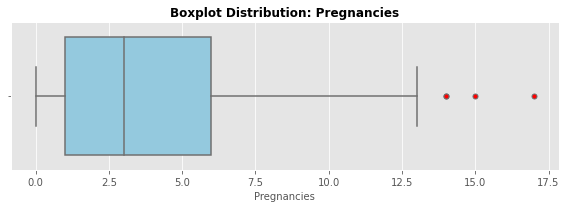

📈 [How to Read the Pregnancies Boxplot]:
  • The center line inside the blue box is the true Median.
  • The left and right box edges mark the 25th (Q1) and 75th (Q3) percentiles.
  • The whiskers extend out to the standard data boundaries.
  • 🟥 Any isolated red circles plotted beyond the whiskers are individual extreme anomalies/outliers.
--------------------------------------------------------------------------------


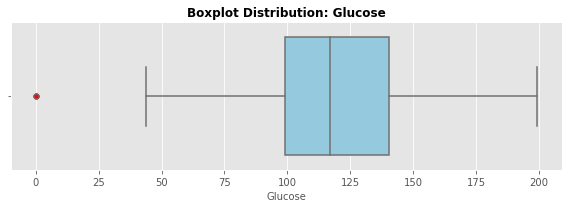

📈 [How to Read the Glucose Boxplot]:
  • The center line inside the blue box is the true Median.
  • The left and right box edges mark the 25th (Q1) and 75th (Q3) percentiles.
  • The whiskers extend out to the standard data boundaries.
  • 🟥 Any isolated red circles plotted beyond the whiskers are individual extreme anomalies/outliers.
--------------------------------------------------------------------------------


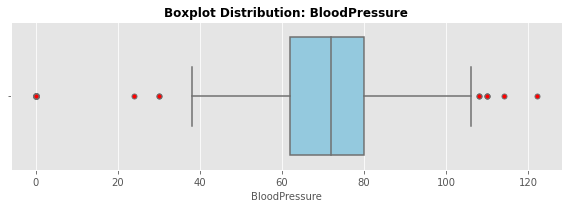

📈 [How to Read the BloodPressure Boxplot]:
  • The center line inside the blue box is the true Median.
  • The left and right box edges mark the 25th (Q1) and 75th (Q3) percentiles.
  • The whiskers extend out to the standard data boundaries.
  • 🟥 Any isolated red circles plotted beyond the whiskers are individual extreme anomalies/outliers.
--------------------------------------------------------------------------------


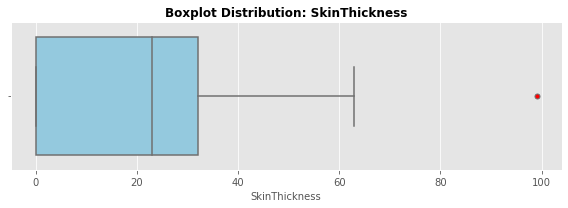

📈 [How to Read the SkinThickness Boxplot]:
  • The center line inside the blue box is the true Median.
  • The left and right box edges mark the 25th (Q1) and 75th (Q3) percentiles.
  • The whiskers extend out to the standard data boundaries.
  • 🟥 Any isolated red circles plotted beyond the whiskers are individual extreme anomalies/outliers.
--------------------------------------------------------------------------------


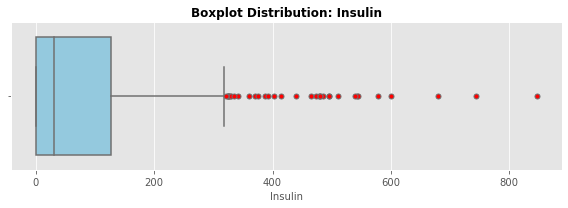

📈 [How to Read the Insulin Boxplot]:
  • The center line inside the blue box is the true Median.
  • The left and right box edges mark the 25th (Q1) and 75th (Q3) percentiles.
  • The whiskers extend out to the standard data boundaries.
  • 🟥 Any isolated red circles plotted beyond the whiskers are individual extreme anomalies/outliers.
--------------------------------------------------------------------------------


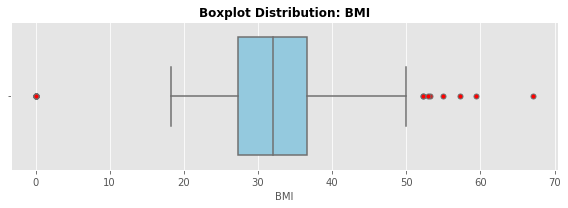

📈 [How to Read the BMI Boxplot]:
  • The center line inside the blue box is the true Median.
  • The left and right box edges mark the 25th (Q1) and 75th (Q3) percentiles.
  • The whiskers extend out to the standard data boundaries.
  • 🟥 Any isolated red circles plotted beyond the whiskers are individual extreme anomalies/outliers.
--------------------------------------------------------------------------------


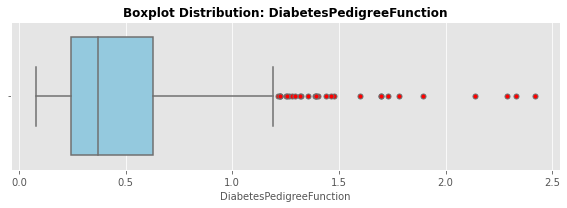

📈 [How to Read the DiabetesPedigreeFunction Boxplot]:
  • The center line inside the blue box is the true Median.
  • The left and right box edges mark the 25th (Q1) and 75th (Q3) percentiles.
  • The whiskers extend out to the standard data boundaries.
  • 🟥 Any isolated red circles plotted beyond the whiskers are individual extreme anomalies/outliers.
--------------------------------------------------------------------------------


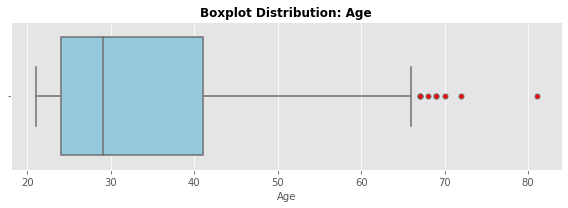

📈 [How to Read the Age Boxplot]:
  • The center line inside the blue box is the true Median.
  • The left and right box edges mark the 25th (Q1) and 75th (Q3) percentiles.
  • The whiskers extend out to the standard data boundaries.
  • 🟥 Any isolated red circles plotted beyond the whiskers are individual extreme anomalies/outliers.
--------------------------------------------------------------------------------


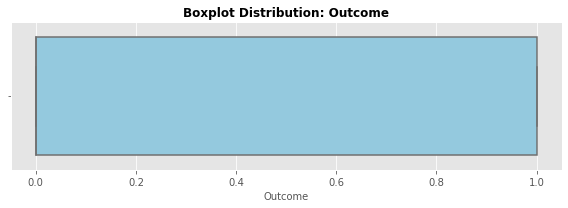

📈 [How to Read the Outcome Boxplot]:
  • The center line inside the blue box is the true Median.
  • The left and right box edges mark the 25th (Q1) and 75th (Q3) percentiles.
  • The whiskers extend out to the standard data boundaries.
  • 🟥 Any isolated red circles plotted beyond the whiskers are individual extreme anomalies/outliers.
--------------------------------------------------------------------------------


In [4]:
print("========== VISUAL DIAGNOSTICS: ANOMALY DETECTION (BOXPLOTS) ==========\n")

for col in num_df.columns:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=num_df[col], color='skyblue', flierprops={'markerfacecolor':'red', 'marker':'o'})
    plt.title(f'Boxplot Distribution: {col}', fontsize=12, fontweight='bold')
    plt.xlabel(col, fontsize=10)
    plt.tight_layout()
    plt.show()
    
    # Detailed dynamic reading guide
    print(f"📈 [How to Read the {col} Boxplot]:")
    print(f"  • The center line inside the blue box is the true Median.")
    print(f"  • The left and right box edges mark the 25th (Q1) and 75th (Q3) percentiles.")
    print(f"  • The whiskers extend out to the standard data boundaries.")
    print(f"  • 🟥 Any isolated red circles plotted beyond the whiskers are individual extreme anomalies/outliers.")
    print("-" * 80)

========== VISUAL DIAGNOSTICS: SKEWNESS & DENSITY DISTRIBUTION ==========



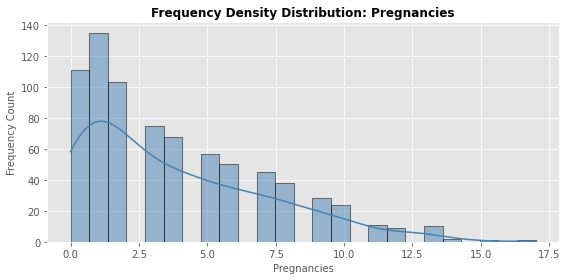

📊 [Distribution Analysis for Pregnancies]:
  • Calculated Skewness Metric: 0.8999
  -> Insight: Right-Skewed Profile. The long trailing tail pulls right. Most patients cluster at lower levels, with few high extreme values.
--------------------------------------------------------------------------------


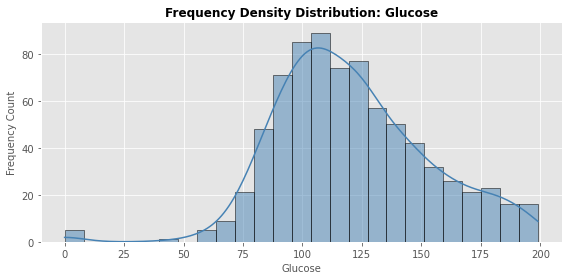

📊 [Distribution Analysis for Glucose]:
  • Calculated Skewness Metric: 0.1734
  -> Insight: Normal Bell Curve shape. The data points balance equally around the true center.
--------------------------------------------------------------------------------


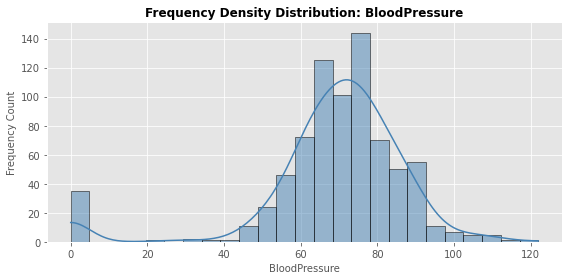

📊 [Distribution Analysis for BloodPressure]:
  • Calculated Skewness Metric: -1.8400
  -> Insight: Left-Skewed Profile. The long tail stretches left. Most patient data points pool at higher tiers.
--------------------------------------------------------------------------------


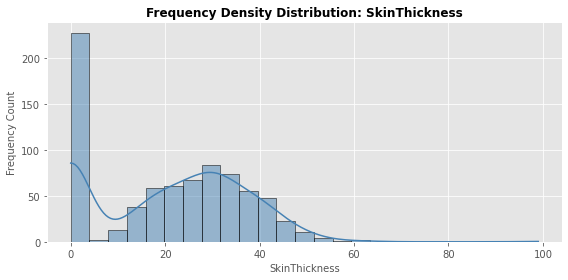

📊 [Distribution Analysis for SkinThickness]:
  • Calculated Skewness Metric: 0.1092
  -> Insight: Normal Bell Curve shape. The data points balance equally around the true center.
--------------------------------------------------------------------------------


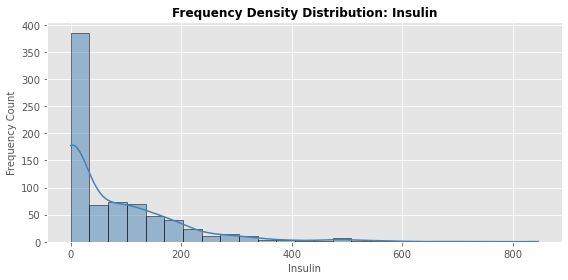

📊 [Distribution Analysis for Insulin]:
  • Calculated Skewness Metric: 2.2678
  -> Insight: Right-Skewed Profile. The long trailing tail pulls right. Most patients cluster at lower levels, with few high extreme values.
--------------------------------------------------------------------------------


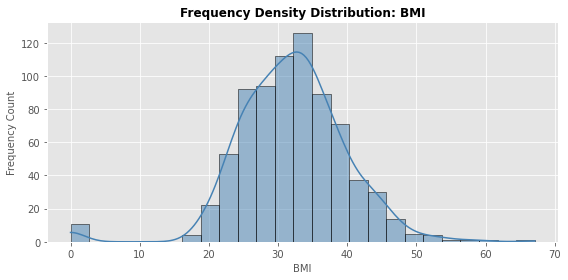

📊 [Distribution Analysis for BMI]:
  • Calculated Skewness Metric: -0.4281
  -> Insight: Normal Bell Curve shape. The data points balance equally around the true center.
--------------------------------------------------------------------------------


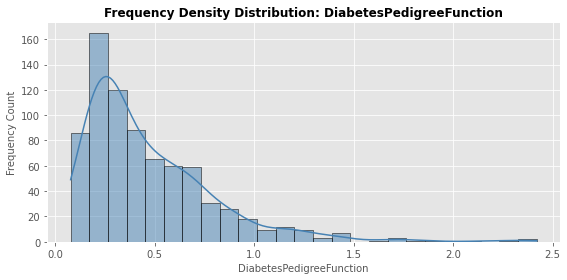

📊 [Distribution Analysis for DiabetesPedigreeFunction]:
  • Calculated Skewness Metric: 1.9162
  -> Insight: Right-Skewed Profile. The long trailing tail pulls right. Most patients cluster at lower levels, with few high extreme values.
--------------------------------------------------------------------------------


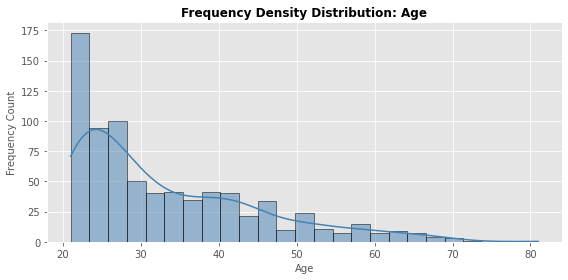

📊 [Distribution Analysis for Age]:
  • Calculated Skewness Metric: 1.1274
  -> Insight: Right-Skewed Profile. The long trailing tail pulls right. Most patients cluster at lower levels, with few high extreme values.
--------------------------------------------------------------------------------


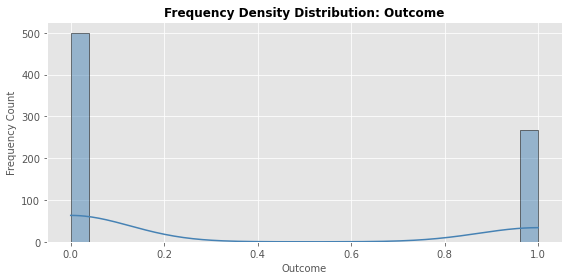

📊 [Distribution Analysis for Outcome]:
  • Calculated Skewness Metric: 0.6338
  -> Insight: Right-Skewed Profile. The long trailing tail pulls right. Most patients cluster at lower levels, with few high extreme values.
--------------------------------------------------------------------------------


In [5]:
print("========== VISUAL DIAGNOSTICS: SKEWNESS & DENSITY DISTRIBUTION ==========\n")

for col in num_df.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(num_df[col], bins=25, kde=True, color='steelblue', edgecolor='black')
    plt.title(f'Frequency Density Distribution: {col}', fontsize=12, fontweight='bold')
    plt.xlabel(col, fontsize=10)
    plt.ylabel("Frequency Count", fontsize=10)
    plt.tight_layout()
    plt.show()
    
    # Mathematical calculation for skewness
    sk = skew(num_df[col].dropna())
    print(f"📊 [Distribution Analysis for {col}]:")
    print(f"  • Calculated Skewness Metric: {sk:.4f}")
    if abs(sk) < 0.5:
        print(f"  -> Insight: Normal Bell Curve shape. The data points balance equally around the true center.")
    elif sk >= 0.5:
        print(f"  -> Insight: Right-Skewed Profile. The long trailing tail pulls right. Most patients cluster at lower levels, with few high extreme values.")
    else:
        print(f"  -> Insight: Left-Skewed Profile. The long tail stretches left. Most patient data points pool at higher tiers.")
    print("-" * 80)

========== SYNERGY METRICS: CORRELATION HEATMAP ==========



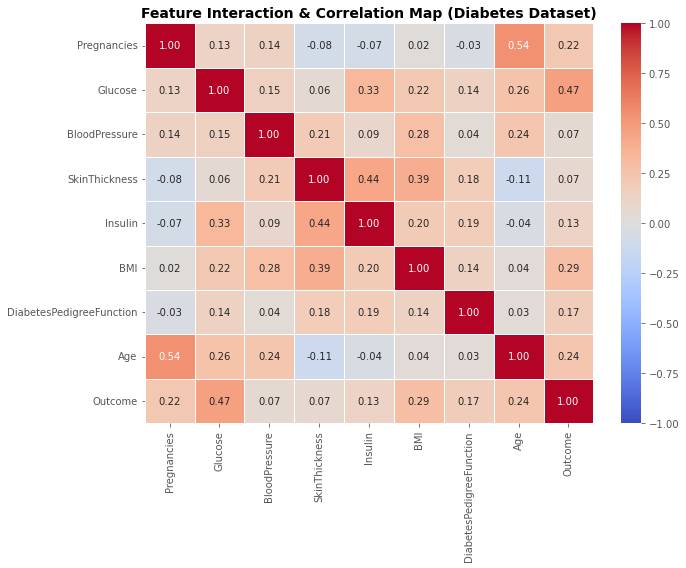

💡 [Correlation Map Interpretations & Key Medical Discoveries]:
  • Pearson Value (r) Rules: +1.00 is perfectly aligned progression, 0.00 is random noise, and -1.00 is an inverted mirror image.

  🥇 Strongest Direct Linear Trend: Between Pregnancies and Age (r = 0.54).
     Meaning: If one index measurement shifts up, the other is statistically likely to follow.
  🥈 Strongest Inverse Linear Trend: Between SkinThickness and Age (r = -0.11).

  🎯 Clinical Diagnosis Insight (Outcome Drivers):
     The absolute top metric showing linear correlation to a positive Diabetes Outcome is 'Glucose' (r = 0.47).
     Second most influential: 'BMI' (r = 0.29).


In [6]:
print("========== SYNERGY METRICS: CORRELATION HEATMAP ==========\n")

plt.figure(figsize=(10, 8))
corr_matrix = num_df.corr()

# Plot clean annotated heatmap matrix
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title("Feature Interaction & Correlation Map (Diabetes Dataset)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("💡 [Correlation Map Interpretations & Key Medical Discoveries]:")
print("  • Pearson Value (r) Rules: +1.00 is perfectly aligned progression, 0.00 is random noise, and -1.00 is an inverted mirror image.")

# Programmatically isolate strongest patterns
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1.0] # Strip self-matching values

if len(corr_pairs) > 0:
    strongest_feat = corr_pairs.index[0]
    weakest_feat = corr_pairs.index[-1]
    
    print(f"\n  🥇 Strongest Direct Linear Trend: Between {strongest_feat[0]} and {strongest_feat[1]} (r = {corr_pairs.iloc[0]:.2f}).")
    print(f"     Meaning: If one index measurement shifts up, the other is statistically likely to follow.")
    
    print(f"  🥈 Strongest Inverse Linear Trend: Between {weakest_feat[0]} and {weakest_feat[1]} (r = {corr_pairs.iloc[-1]:.2f}).")
    
    # Medical Diagnosis Target Tracking
    if 'Outcome' in corr_matrix.columns:
        outcome_corr = corr_matrix['Outcome'].drop('Outcome').sort_values(ascending=False)
        print(f"\n  🎯 Clinical Diagnosis Insight (Outcome Drivers):")
        print(f"     The absolute top metric showing linear correlation to a positive Diabetes Outcome is '{outcome_corr.index[0]}' (r = {outcome_corr.iloc[0]:.2f}).")
        print(f"     Second most influential: '{outcome_corr.index[1]}' (r = {outcome_corr.iloc[1]:.2f}).")

========== MULTI-DIMENSIONAL VISUAL CLUSTERING (PAIR PLOT) ==========

⏳ Building the relational scatter grid matrix. Please hold for rendering...


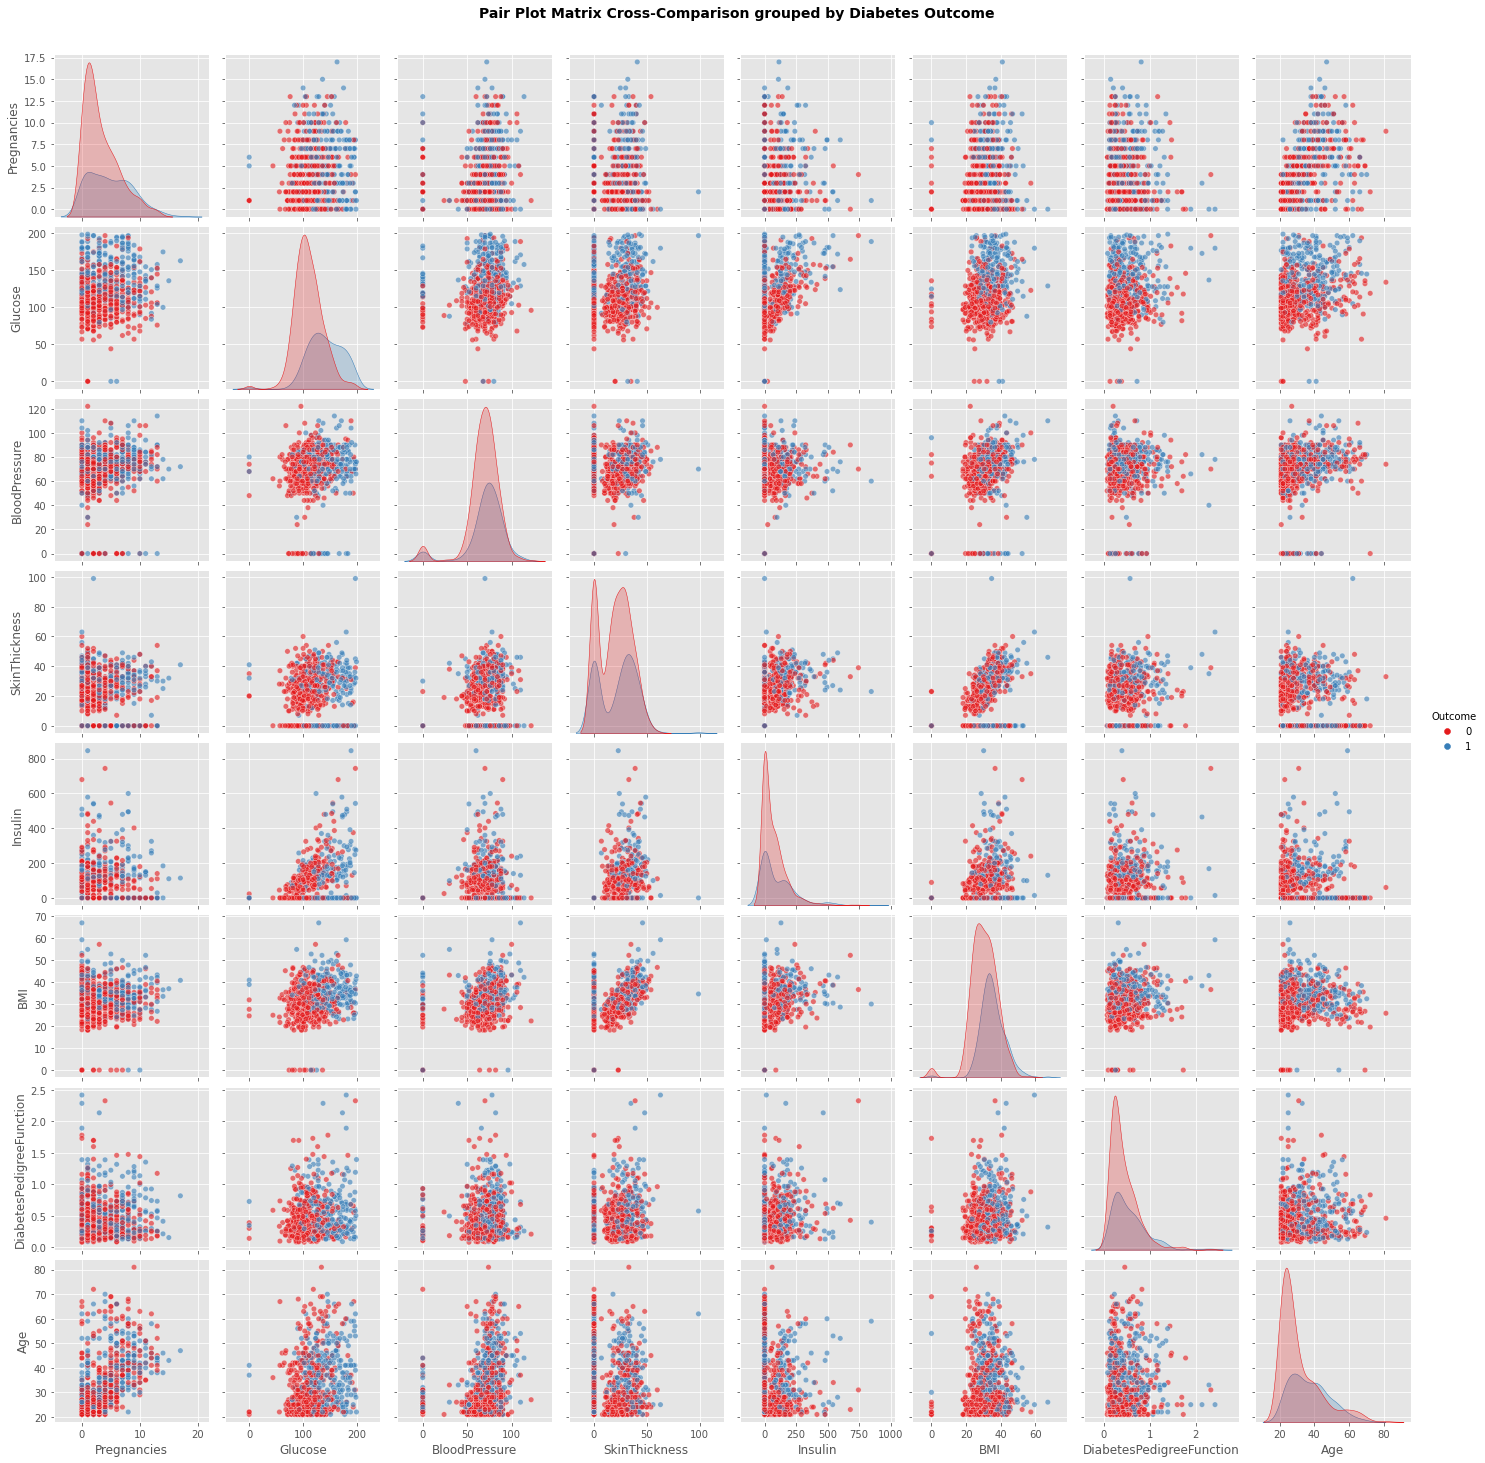


💡 [How to extract patterns from this matrix cluster]:
  • Scan columns or rows matching the 'Outcome' marker category color (e.g., Red vs. Blue).
  • Look for clear, visible separations between colors. Gaps or distinct clusters indicate combinations of variables that clearly distinguish diabetic patients from non-diabetic patients.


In [9]:
print("========== MULTI-DIMENSIONAL VISUAL CLUSTERING (PAIR PLOT) ==========\n")
print("⏳ Building the relational scatter grid matrix. Please hold for rendering...")

# Uses the 'Outcome' classification flag as the color split argument
if 'Outcome' in df.columns:
    g = sns.pairplot(df, hue='Outcome', palette='Set1', diag_kind='kde', plot_kws={'alpha': 0.6, 's': 30})
    plt.suptitle("Pair Plot Matrix Cross-Comparison grouped by Diabetes Outcome", y=1.02, fontsize=14, fontweight='bold')
    plt.show()
    
    print("\n💡 [How to extract patterns from this matrix cluster]:")
    print("  • Scan columns or rows matching the 'Outcome' marker category color (e.g., Red vs. Blue).")
    print("  • Look for clear, visible separations between colors. Gaps or distinct clusters indicate combinations of variables that clearly distinguish diabetic patients from non-diabetic patients.")
else:
    sns.pairplot(num_df, diag_kind='kde')
    plt.show()

========== MATHEMATICAL VALIDATION: QUANTILE-QUANTILE (Q-Q) PLOTS ==========



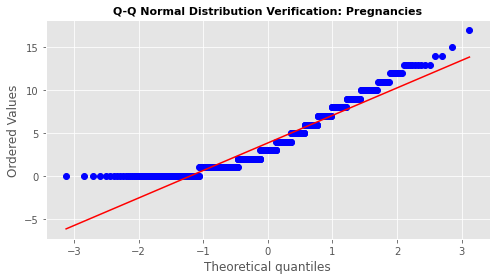

📐 [Q-Q Normality Verdict for 'Pregnancies']:
  • If the blue dataset circles sit directly on top of the red diagonal trendline, your dataset features perfect gaussian normality.
  • Deviations, heavy curves away from the line, or S-shapes at either end indicate that the data violates standard statistical normality rules. This suggests you should use non-parametric tests or apply transformations (like a log transformation) before training machine learning models.
--------------------------------------------------------------------------------


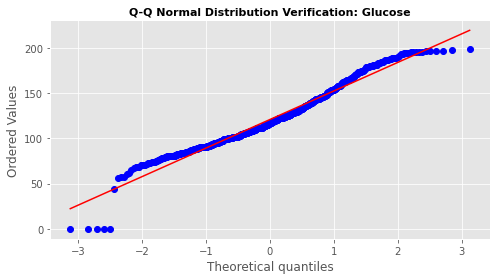

📐 [Q-Q Normality Verdict for 'Glucose']:
  • If the blue dataset circles sit directly on top of the red diagonal trendline, your dataset features perfect gaussian normality.
  • Deviations, heavy curves away from the line, or S-shapes at either end indicate that the data violates standard statistical normality rules. This suggests you should use non-parametric tests or apply transformations (like a log transformation) before training machine learning models.
--------------------------------------------------------------------------------


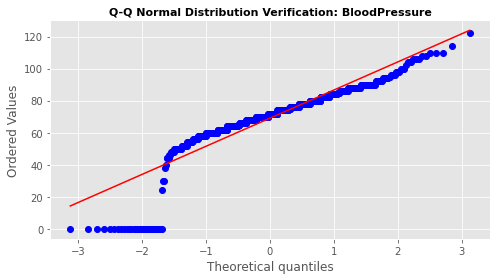

📐 [Q-Q Normality Verdict for 'BloodPressure']:
  • If the blue dataset circles sit directly on top of the red diagonal trendline, your dataset features perfect gaussian normality.
  • Deviations, heavy curves away from the line, or S-shapes at either end indicate that the data violates standard statistical normality rules. This suggests you should use non-parametric tests or apply transformations (like a log transformation) before training machine learning models.
--------------------------------------------------------------------------------


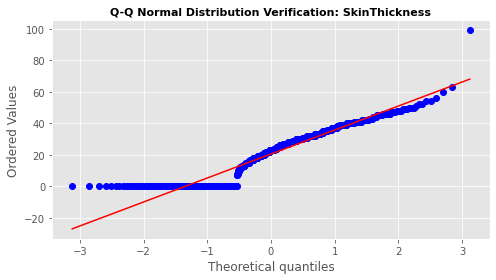

📐 [Q-Q Normality Verdict for 'SkinThickness']:
  • If the blue dataset circles sit directly on top of the red diagonal trendline, your dataset features perfect gaussian normality.
  • Deviations, heavy curves away from the line, or S-shapes at either end indicate that the data violates standard statistical normality rules. This suggests you should use non-parametric tests or apply transformations (like a log transformation) before training machine learning models.
--------------------------------------------------------------------------------


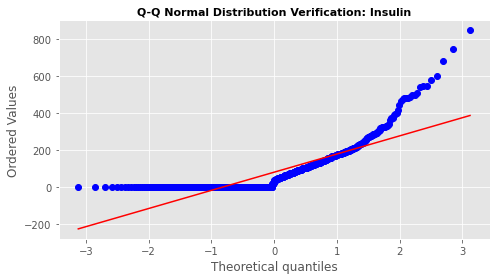

📐 [Q-Q Normality Verdict for 'Insulin']:
  • If the blue dataset circles sit directly on top of the red diagonal trendline, your dataset features perfect gaussian normality.
  • Deviations, heavy curves away from the line, or S-shapes at either end indicate that the data violates standard statistical normality rules. This suggests you should use non-parametric tests or apply transformations (like a log transformation) before training machine learning models.
--------------------------------------------------------------------------------


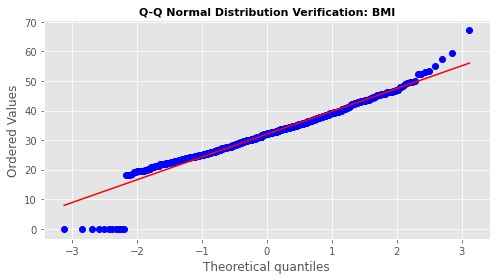

📐 [Q-Q Normality Verdict for 'BMI']:
  • If the blue dataset circles sit directly on top of the red diagonal trendline, your dataset features perfect gaussian normality.
  • Deviations, heavy curves away from the line, or S-shapes at either end indicate that the data violates standard statistical normality rules. This suggests you should use non-parametric tests or apply transformations (like a log transformation) before training machine learning models.
--------------------------------------------------------------------------------


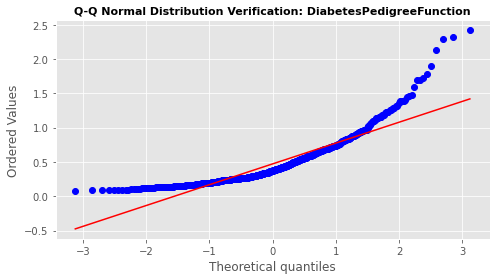

📐 [Q-Q Normality Verdict for 'DiabetesPedigreeFunction']:
  • If the blue dataset circles sit directly on top of the red diagonal trendline, your dataset features perfect gaussian normality.
  • Deviations, heavy curves away from the line, or S-shapes at either end indicate that the data violates standard statistical normality rules. This suggests you should use non-parametric tests or apply transformations (like a log transformation) before training machine learning models.
--------------------------------------------------------------------------------


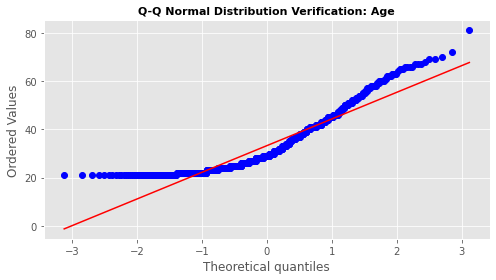

📐 [Q-Q Normality Verdict for 'Age']:
  • If the blue dataset circles sit directly on top of the red diagonal trendline, your dataset features perfect gaussian normality.
  • Deviations, heavy curves away from the line, or S-shapes at either end indicate that the data violates standard statistical normality rules. This suggests you should use non-parametric tests or apply transformations (like a log transformation) before training machine learning models.
--------------------------------------------------------------------------------


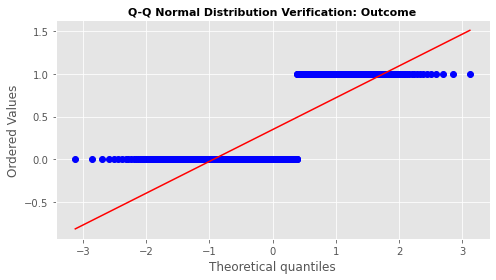

📐 [Q-Q Normality Verdict for 'Outcome']:
  • If the blue dataset circles sit directly on top of the red diagonal trendline, your dataset features perfect gaussian normality.
  • Deviations, heavy curves away from the line, or S-shapes at either end indicate that the data violates standard statistical normality rules. This suggests you should use non-parametric tests or apply transformations (like a log transformation) before training machine learning models.
--------------------------------------------------------------------------------

🚀 ========== All Analysis Modules Completed Successfully! ==========


In [8]:
print("========== MATHEMATICAL VALIDATION: QUANTILE-QUANTILE (Q-Q) PLOTS ==========\n")

for col in num_df.columns:
    plt.figure(figsize=(7, 4))
    probplot(num_df[col].dropna(), dist="norm", plot=plt)
    
    # Custom styling override for scipy's raw defaults
    plt.title(f'Q-Q Normal Distribution Verification: {col}', fontsize=11, fontweight='bold')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    print(f"📐 [Q-Q Normality Verdict for '{col}']:")
    print("  • If the blue dataset circles sit directly on top of the red diagonal trendline, your dataset features perfect gaussian normality.")
    print("  • Deviations, heavy curves away from the line, or S-shapes at either end indicate that the data violates standard statistical normality rules. This suggests you should use non-parametric tests or apply transformations (like a log transformation) before training machine learning models.")
    print("-" * 80)

print("\n🚀 ========== All Analysis Modules Completed Successfully! ==========")